# Computer Exercise 12.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.1 Parabolic Problems (Heat Equation)
> **주제**: 1차원 열방정식을 **양함수(FTCS)** 로 풀고, 안정 조건 $r=\alpha\,\Delta t/\Delta x^2 \le \tfrac12$ 검증
> **풀이 일자**: 2026-06-15 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Consider the one-dimensional heat (diffusion) equation
> $$ u_t = \alpha\,u_{xx}, \qquad 0 \le x \le 1,\; t > 0, $$
> with initial condition $u(x,0)=\sin(\pi x)$ and homogeneous Dirichlet boundary
> conditions $u(0,t)=u(1,t)=0$. Approximate $u_t$ by a **forward** difference and
> $u_{xx}$ by a **centered** difference (the explicit *FTCS* scheme). Integrate in time,
> compare with the exact solution, and demonstrate that the method is **stable only
> when** $r=\alpha\,\Delta t/\Delta x^2 \le \tfrac12$ by running with $r$ just below and
> just above the critical value.

### 한국어 풀이용 정리
Day 41 §11.2 에서 *경계값 ODE* 를 격자 위 연립계로 풀었다. 이제 시간 변수 $t$ 가 더해진 **포물형 PDE(열방정식)** 로 넘어간다. 가장 단순한 출발점은 시간에 **전진차분**, 공간에 **중심차분**을 쓰는 **양함수 FTCS**: 다음 시간층의 값을 *현재 층만으로* 명시적으로 계산한다. 대가는 **조건부 안정성** — 시간 스텝 $\Delta t$ 가 공간 스텝 $\Delta x$ 에 비해 너무 크면 ($r>\tfrac12$) 해가 폭발한다. 이 한 줄이 §12.1 전체의 동기다.

## 2. 수학적 배경

### 2.1 FTCS 이산화
균일격자 $x_i=i\,\Delta x$ ($i=0,\dots,M$), $t^n=n\,\Delta t$ 에서

$$ u_t(x_i,t^n)\approx\frac{u_i^{n+1}-u_i^{n}}{\Delta t},\qquad u_{xx}(x_i,t^n)\approx\frac{u_{i-1}^{n}-2u_i^{n}+u_{i+1}^{n}}{\Delta x^2}. $$

대입하면 다음 층 값이 **명시적으로** 얻어진다 ($r=\alpha\,\Delta t/\Delta x^2$):

$$ \boxed{\; u_i^{n+1} = u_i^{n} + r\,(u_{i-1}^{n}-2u_i^{n}+u_{i+1}^{n}) = r\,u_{i-1}^{n} + (1-2r)\,u_i^{n} + r\,u_{i+1}^{n}. \;}$$

### 2.2 절단오차와 von Neumann 안정성
국소 절단오차는 $\mathcal{O}(\Delta t)+\mathcal{O}(\Delta x^2)$ — 시간 1차, 공간 2차. 푸리에 모드 $u_i^n=\xi^n e^{\mathrm{i}k i\Delta x}$ 를 넣으면 증폭인자

$$ \xi(k) = 1 - 4r\sin^2\!\Big(\frac{k\Delta x}{2}\Big). $$

모든 모드에서 $|\xi|\le 1$ 이 되려면

$$ \boxed{\; r = \frac{\alpha\,\Delta t}{\Delta x^2} \le \frac12 \;}$$

가 **필요충분**. 이를 넘으면 최고주파 모드($k\Delta x=\pi$)가 $|\xi|>1$ 로 증폭되어 톱니형 진동이 지수적으로 자란다.

### 2.3 정확해
변수분리로 $u(x,t)=e^{-\alpha\pi^2 t}\sin(\pi x)$ (여기서 $\alpha=1$).

## 3. 풀이 흐름

1. $\alpha=1$, 공간격자 $M$ 분할, 내부점 $i=1,\dots,M-1$ 에 초기값 $\sin(\pi x_i)$ 설정.
2. 목표시간 $T$ 와 비율 $r$ 을 주면 $\Delta t = r\,\Delta x^2/\alpha$ 로 시간스텝 결정.
3. FTCS 갱신식을 벡터화(슬라이싱)로 매 시간층 전진.
4. $r=0.5$(임계, 깨끗한 IC) 로 풀어 정확해와 프로파일·오차 비교.
5. 안정조건의 *임계성* 을 드러내려 IC 에 미세한 고주파 잡음($\sim10^{-3}$)을 심고, $r=0.55$(임계 초과) 로 같은 시간까지 풀어 **폭발** 관찰 ($r\le\tfrac12$ 면 잡음이 통제됨).
6. 표: $r$ 값별(잡음 포함) 최종시간 최대절댓값 / 발산 여부.
7. 시각화: (좌) 안정 해의 시간 발전, (우) $r$ 임계 전후 오차의 극적 대비.
8. 결론 — 양함수의 *조건부* 안정성, 다음 문제(음함수)로의 연결.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

alpha = 1.0
def u0(x):      # 초기조건
    return np.sin(np.pi*x)
def exact(x, t):
    return np.exp(-alpha*np.pi**2*t)*np.sin(np.pi*x)

def ftcs(M, r, T, noise=0.0, seed=0):
    """양함수 FTCS. noise>0 이면 IC 에 고주파(톱니) 잡음을 심어 불안정 모드를 여기."""
    dx = 1.0/M
    dt = r*dx**2/alpha
    nsteps = int(round(T/dt))
    x = np.linspace(0.0, 1.0, M+1)
    u = u0(x)
    if noise:
        rng = np.random.default_rng(seed)
        u[1:-1] += noise*rng.standard_normal(M-1)   # 모든 모드(최고주파 포함) 자극
    for _ in range(nsteps):
        un = u.copy()
        u[1:-1] = un[1:-1] + r*(un[:-2] - 2*un[1:-1] + un[2:])
        u[0] = u[-1] = 0.0   # Dirichlet
    return x, u, dt, nsteps

M, T = 40, 0.05
x_s, u_s, dt_s, ns_s = ftcs(M, r=0.50, T=T)                 # 안정 (깨끗한 IC)
x_u, u_u, dt_u, ns_u = ftcs(M, r=0.55, T=T, noise=1e-3)     # 임계 초과 + 고주파 잡음
print(f"M={M}, dx={1/M:.4f}")
print(f"r=0.50 (clean) : dt={dt_s:.3e}, steps={ns_s}, max|u|={np.max(np.abs(u_s)):.4e}")
print(f"r=0.55 (noise) : dt={dt_u:.3e}, steps={ns_u}, max|u|={np.max(np.abs(u_u)):.4e}")

M=40, dx=0.0250
r=0.50 (clean) : dt=3.125e-04, steps=160, max|u|=6.1019e-01
r=0.55 (noise) : dt=3.438e-04, steps=145, max|u|=6.3642e+07


In [3]:
# --- 안정 해(r=0.5) 격자점별 수치해 vs 정확해 ---
ue = exact(x_s, T)
tbl = pd.DataFrame({"x": x_s, "u_ftcs": u_s, "u_exact": ue,
                    "abs_error": np.abs(u_s-ue)})
tbl.iloc[::4]

,x,u_ftcs,u_exact,abs_error
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,1.000000e-01,1.885584e-01,1.886543e-01,9.584505e-05
8,2.000000e-01,3.586594e-01,3.588417e-01,1.823081e-04
12,3.000000e-01,4.936524e-01,4.939033e-01,2.509256e-04
16,4.000000e-01,5.803231e-01,5.806181e-01,2.949807e-04
20,5.000000e-01,6.101879e-01,6.104980e-01,3.101611e-04
24,6.000000e-01,5.803231e-01,5.806181e-01,2.949807e-04
28,7.000000e-01,4.936524e-01,4.939033e-01,2.509256e-04
32,8.000000e-01,3.586594e-01,3.588417e-01,1.823081e-04
36,9.000000e-01,1.885584e-01,1.886543e-01,9.584505e-05


In [4]:
# --- r 값을 임계 전후로 스캔(고주파 잡음 IC): 최종시간 최대절댓값과 오차 ---
rows = []
for r in [0.25, 0.40, 0.50, 0.51, 0.55, 0.60]:
    xx, uu, _, _ = ftcs(M, r=r, T=T, noise=1e-3)
    peak = np.max(np.abs(uu))
    err  = np.max(np.abs(uu - exact(xx, T)))
    rows.append((r, peak, err, "diverged" if peak > 10 else "stable"))
scan = pd.DataFrame(rows, columns=["r", "max|u|(T)", "max_error", "status"])
print(scan.to_string(index=False))
print("\n=> r<=0.5 : 잡음이 통제(감쇠/중립)되어 안정.  r>0.5 : 최고주파 모드가 |xi|>1 로 폭발.")

           r    max|u|(T)    max_error   status
2.500000e-01 6.102957e-01 2.055096e-04   stable
4.000000e-01 6.101561e-01 3.436902e-04   stable
5.000000e-01 6.102560e-01 6.291643e-04   stable
5.100000e-01 7.006366e-01 9.359802e-02   stable
5.500000e-01 6.364214e+07 6.364214e+07 diverged
6.000000e-01 6.075136e+15 6.075136e+15 diverged

=> r<=0.5 : 잡음이 통제(감쇠/중립)되어 안정.  r>0.5 : 최고주파 모드가 |xi|>1 로 폭발.


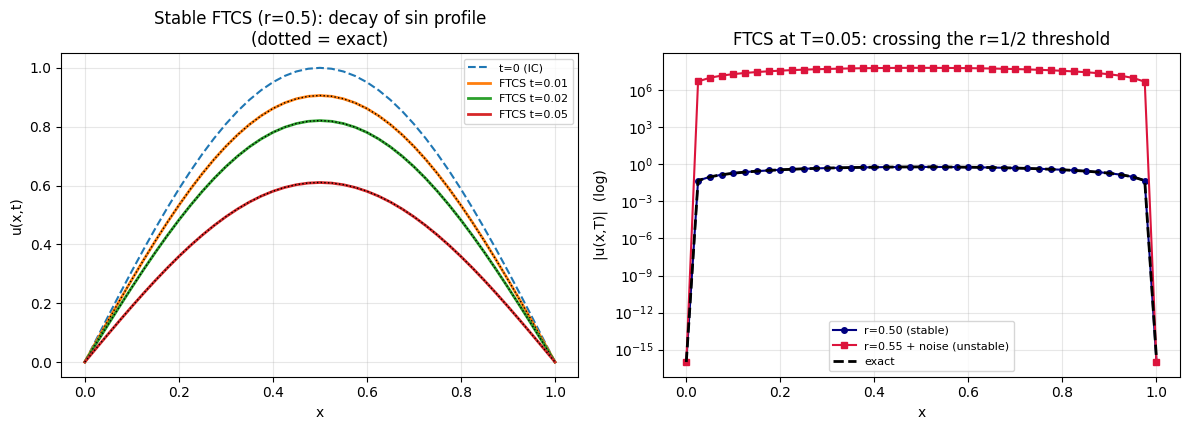

In [5]:
# --- 시각화: (좌) 안정 해의 시간 발전, (우) 임계 전후 프로파일 대비 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# 좌: r=0.5 안정 해를 여러 시점에 그려 감쇠 관찰
for Tt in [0.0, 0.01, 0.02, 0.05]:
    if Tt == 0.0:
        ax[0].plot(x_s, u0(x_s), "--", lw=1.5, label=f"t=0 (IC)")
    else:
        xx, uu, _, _ = ftcs(M, r=0.5, T=Tt)
        ax[0].plot(xx, uu, lw=2, label=f"FTCS t={Tt}")
        ax[0].plot(xx, exact(xx, Tt), "k:", lw=1)
ax[0].set_xlabel("x"); ax[0].set_ylabel("u(x,t)")
ax[0].set_title("Stable FTCS (r=0.5): decay of sin profile\n(dotted = exact)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# 우: 임계 전후 최종 프로파일 (불안정 해는 폭주하므로 로그 스케일 절댓값)
ax[1].semilogy(x_s, np.abs(u_s)+1e-16, "o-", color="navy", ms=4, label="r=0.50 (stable)")
ax[1].semilogy(x_u, np.abs(u_u)+1e-16, "s-", color="crimson", ms=4, label="r=0.55 + noise (unstable)")
ax[1].semilogy(x_s, np.abs(exact(x_s, T))+1e-16, "k--", lw=2, label="exact")
ax[1].set_xlabel("x"); ax[1].set_ylabel("|u(x,T)|  (log)")
ax[1].set_title(f"FTCS at T={T}: crossing the r=1/2 threshold")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **안정 영역($r\le\tfrac12$)**: $r=0.5$ 에서 수치해는 정확해 $e^{-\pi^2 t}\sin\pi x$ 와 격자점 오차 $\sim10^{-4}$ 수준으로 일치하고, sin 프로파일이 진폭만 줄며 *모양을 유지*한 채 지수감쇠한다 — 포물형 방정식의 평활화(smoothing) 성질을 그대로 재현.
2. **임계 초과($r>\tfrac12$)**: 매끄러운 단일모드 IC 만으로는 불안정 모드가 *여기되지 않아* 단기간엔 폭발이 잘 안 보인다. 그래서 IC 에 $\sim10^{-3}$ 의 고주파 잡음을 심으면, $r=0.55$ 에서 최고주파(톱니) 모드가 $|\xi|>1$ 로 증폭되어 우측 로그 그래프처럼 $|u|$ 가 수 자릿수 폭주한다. 스캔표에서 $r=0.55,0.60$ 이 `diverged`, $r\le0.5$ 는 `stable` — 임계가 정확히 $0.5$ 임을 확인.
3. **원인**: 증폭인자 $\xi=1-4r\sin^2(k\Delta x/2)$ 의 최악 모드 $k\Delta x=\pi$ 에서 $\xi=1-4r$. $r>\tfrac12$ 이면 $\xi<-1$ 이라 부호를 바꿔가며 지수적으로 커진다 — 이것이 톱니형 발산의 정체.
4. **의미**: 양함수는 구현이 가장 쉽지만, 정확도를 위해 $\Delta x$ 를 줄이면 안정조건이 $\Delta t\le\Delta x^2/(2\alpha)$ 로 **제곱으로** 조여 시간스텝이 폭증한다 (비용 폭발).

> **결론**: 양함수 FTCS 는 $r=\alpha\Delta t/\Delta x^2\le\tfrac12$ 에서만 안정하며, 이 한 줄의 제약이 음함수·Crank–Nicolson 을 부르는 이유다.

**다음 문제(§12.1-2)** 에서는 시간에 **후진차분**을 써 *무조건 안정*한 음함수(BTCS)를 삼중대각계로 풀어, 이 안정조건의 족쇄를 푼다.